In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, roc_curve, auc)

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style('whitegrid')

stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()
STOPWORDS  = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
# STEP 1 — DATA COLLECTION

df = pd.read_csv('tweet_emotions.csv')
print(f"Total Tweets : {len(df):,}")
print(df['sentiment'].value_counts())
print(df.head())
pos_labels = ['happiness', 'love', 'fun', 'enthusiasm', 'relief']
neg_labels = ['sadness', 'worry', 'hate', 'anger', 'boredom']
df = df[df['sentiment'].isin(pos_labels + neg_labels)].copy()
df['label'] = df['sentiment'].apply(
    lambda x: 'positive' if x in pos_labels else 'negative'
)
print(f"\nAfter Mapping : {df['label'].value_counts().to_dict()}")

Total Tweets : 40,000
sentiment
neutral       8638
worry         8459
happiness     5209
sadness       5165
love          3842
surprise      2187
fun           1776
relief        1526
hate          1323
empty          827
enthusiasm     759
boredom        179
anger          110
Name: count, dtype: int64
     tweet_id   sentiment                                            content
0  1956967341       empty  @tiffanylue i know  i was listenin to bad habi...
1  1956967666     sadness  Layin n bed with a headache  ughhhh...waitin o...
2  1956967696     sadness                Funeral ceremony...gloomy friday...
3  1956967789  enthusiasm               wants to hang out with friends SOON!
4  1956968416     neutral  @dannycastillo We want to trade with someone w...

After Mapping : {'negative': 15236, 'positive': 13112}


In [ ]:
# STEP 2 — TEXT CLEANING (10 Steps)

def clean_text(text):
    text = str(text).lower()                             # 1. Lowercase
    text = re.sub(r'http\S+|www\S+', '', text)           # 2. Remove URLs
    text = re.sub(r'@\w+', '', text)                     # 3. Remove @mentions
    text = re.sub(r'#\w+', '', text)                     # 4. Remove hashtags
    text = re.sub(r'[^a-z0-9\s]', ' ', text)            # 5. Remove special chars
    text = re.sub(r'\d+', '', text)                      # 6. Remove numbers
    text = re.sub(r'\s+', ' ', text).strip()             # 7. Remove extra spaces
    tokens = word_tokenize(text)                         # 8. NLTK Tokenization
    tokens = [t for t in tokens                          # 9. Remove stopwords
              if t not in STOPWORDS and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]  # 10. NLTK Lemmatization
    tokens = [stemmer.stem(t) for t in tokens]           # 11. NLTK Stemming
    tokens = [re.sub(r'(.)\1{2,}', r'\1\1', t)          # 12. Normalize repeated chars
              for t in tokens]
    return ' '.join(tokens)

print("Applying NLP pipeline to all tweets...")
df['clean'] = df['content'].apply(clean_text)
print(f"\nBEFORE : {df['content'].iloc[1]}")
print(f"AFTER  : {df['clean'].iloc[1]}")

Applying NLP pipeline to all tweets...

BEFORE : Funeral ceremony...gloomy friday...
AFTER  : funer ceremoni gloomi friday


In [ ]:
# STEP 3 — TOKENIZATION

sample_tokens = word_tokenize(df['content'].iloc[3].lower())
print("NLTK Tokenization:")
print(f"  Tokens : {sample_tokens[:10]}")
print(f"  Count  : {len(sample_tokens)} tokens")

NLTK Tokenization:
  Tokens : ['re-pinging', '@', 'ghostridah14', ':', 'why', 'did', "n't", 'you', 'go', 'to']
  Count  : 20 tokens


In [ ]:
# STEP 4 — STOPWORD REMOVAL

before = word_tokenize(df['content'].iloc[3].lower())
after  = [t for t in before if t not in STOPWORDS]
print(f"Total NLTK Stopwords : {len(STOPWORDS)}")
print(f"Before : {before[:8]}")
print(f"After  : {after[:8]}")
print(f"Removed : {len(before) - len(after)} words")

Total NLTK Stopwords : 198
Before : ['re-pinging', '@', 'ghostridah14', ':', 'why', 'did', "n't", 'you']
After  : ['re-pinging', '@', 'ghostridah14', ':', "n't", 'go', 'prom', '?']
Removed : 7 words


In [ ]:
# STEP 5 — STEMMING

print("NLTK PorterStemmer Examples:")
for word in ['running', 'happiness', 'worried', 'loving', 'beautiful', 'caring']:
    print(f"  {word:15s} → {stemmer.stem(word)}")

NLTK PorterStemmer Examples:
  running         → run
  happiness       → happi
  worried         → worri
  loving          → love
  beautiful       → beauti
  caring          → care


In [ ]:
# STEP 6 — LEMMATIZATION

print("NLTK WordNetLemmatizer Examples:")
for word in ['running', 'loved', 'better', 'worried', 'studies', 'are']:
    print(f"  {word:15s} → {lemmatizer.lemmatize(word)}")

NLTK WordNetLemmatizer Examples:
  running         → running
  loved           → loved
  better          → better
  worried         → worried
  studies         → study
  are             → are


In [ ]:
# STEP 7 — TEXT NORMALIZATION

raw = "I am SOOOOO happppy!!! @john check http://t.co/xyz #mood 123"
print(f"Raw   : {raw}")
print(f"Clean : {clean_text(raw)}")

Raw   : I am SOOOOO happppy!!! @john check http://t.co/xyz #mood 123
Clean : soo happi check


In [ ]:
# STEP 8 — FEATURE EXTRACTION

X = df['clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train : {len(X_train):,}  |  Test : {len(X_test):,}")

# Bag of Words
bow     = CountVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2)
Xtr_bow = bow.fit_transform(X_train)
Xte_bow = bow.transform(X_test)
print(f"\nBag of Words Matrix : {Xtr_bow.shape}")
print(f"Sample BoW features : {bow.get_feature_names_out()[:6].tolist()}")

# TF-IDF (word + char n-grams)
w_tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=60000,
                           sublinear_tf=True, min_df=2)
c_tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5),
                           max_features=30000, sublinear_tf=True, min_df=2)
Xtr = sp.hstack([w_tfidf.fit_transform(X_train), c_tfidf.fit_transform(X_train)])
Xte = sp.hstack([w_tfidf.transform(X_test),      c_tfidf.transform(X_test)])
print(f"\nTF-IDF Matrix : {Xtr.shape}  (word + char n-grams)")

Train : 22,678  |  Test : 5,670

Bag of Words Matrix : (22678, 19897)
Sample BoW features : ['aa', 'aah', 'aahh', 'aand', 'aargh', 'aaron']

TF-IDF Matrix : (22678, 49897)  (word + char n-grams)


In [ ]:
# STEP 9 — MODEL BUILDING

model = LogisticRegression(C=5, max_iter=1000, solver='saga', n_jobs=-1)
model.fit(Xtr, y_train)
preds  = model.predict(Xte)
proba  = model.predict_proba(Xte)[:, list(model.classes_).index('positive')]
print("Logistic Regression — Training Complete ✓")
print(f"  C        : 5")
print(f"  Solver   : saga")
print(f"  Max Iter : 1000")

Logistic Regression — Training Complete ✓
  C        : 5
  Solver   : saga
  Max Iter : 1000


In [ ]:
# STEP 10 — EVALUATION METRICS

acc     = accuracy_score(y_test, preds)
prec    = precision_score(y_test, preds, pos_label='positive')
rec     = recall_score(y_test, preds, pos_label='positive')
f1      = f1_score(y_test, preds, pos_label='positive')
fpr, tpr, _ = roc_curve(y_test, proba, pos_label='positive')
roc_auc = auc(fpr, tpr)

print(f"Accuracy  : {acc:.4f}  ({acc*100:.1f}%)")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"\n{classification_report(y_test, preds)}")

Accuracy  : 0.7416  (74.2%)
Precision : 0.7232
Recall    : 0.7152
F1-Score  : 0.7192
ROC-AUC   : 0.8225

              precision    recall  f1-score   support

    negative       0.76      0.76      0.76      3047
    positive       0.72      0.72      0.72      2623

    accuracy                           0.74      5670
   macro avg       0.74      0.74      0.74      5670
weighted avg       0.74      0.74      0.74      5670



In [ ]:

# STEP 11 — PREDICTION

def predict_tweet(text):
    c    = clean_text(text)
    Xnew = sp.hstack([w_tfidf.transform([c]), c_tfidf.transform([c])])
    pred = model.predict(Xnew)[0]
    conf = max(model.predict_proba(Xnew)[0]) * 100
    return pred, conf

new_tweets = [
    "I am so happy today, feeling absolutely great!",
    "This is the worst day ever, I hate everything",
    "I love spending time with my family!",
    "I'm really worried and stressed about tomorrow",
    "Had so much fun at the party last night!!",
    "Feeling sad and bored, nothing going right",
]
print("Predictions:")
for tweet in new_tweets:
    pred, conf = predict_tweet(tweet)
    icon = '😊' if pred == 'positive' else '😟'
    print(f"  {icon} [{pred.upper():8s} {conf:.1f}%]  {tweet}")

Predictions:
  😊 [POSITIVE 91.0%]  I am so happy today, feeling absolutely great!
  😟 [NEGATIVE 99.4%]  This is the worst day ever, I hate everything
  😟 [NEGATIVE 52.3%]  I love spending time with my family!
  😟 [NEGATIVE 83.2%]  I'm really worried and stressed about tomorrow
  😊 [POSITIVE 92.5%]  Had so much fun at the party last night!!
  😟 [NEGATIVE 99.5%]  Feeling sad and bored, nothing going right


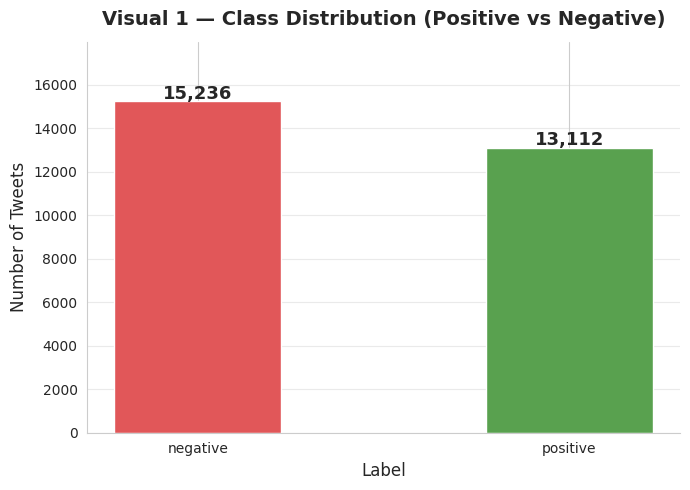

In [ ]:
# VISUAL 1 — Class Distribution

counts = df['label'].value_counts()
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(counts.index, counts.values,
              color=['#e15759', '#59a14f'], edgecolor='white', width=0.45, zorder=2)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 120,
            f'{val:,}', ha='center', fontsize=13, fontweight='bold')
ax.set_title('Visual 1 — Class Distribution (Positive vs Negative)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Label', fontsize=12)
ax.set_ylabel('Number of Tweets', fontsize=12)
ax.set_ylim(0, counts.max() * 1.18)
ax.yaxis.grid(True, alpha=0.4, zorder=0)
sns.despine()
plt.tight_layout()
plt.show()

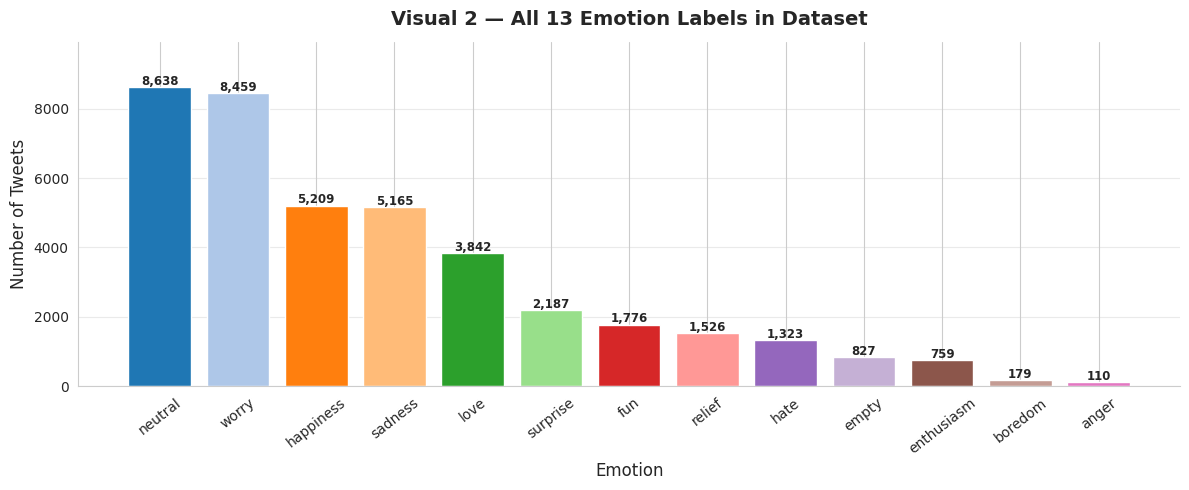

In [ ]:
# VISUAL 2 — Original 13 Emotion Distribution

original_df = pd.read_csv('tweet_emotions.csv')
orig_counts = original_df['sentiment'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette('tab20', len(orig_counts))
bars = ax.bar(orig_counts.index, orig_counts.values,
              color=palette, edgecolor='white', zorder=2)
for bar, val in zip(bars, orig_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
            f'{val:,}', ha='center', fontsize=8.5, fontweight='bold')
ax.set_title('Visual 2 — All 13 Emotion Labels in Dataset', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Emotion', fontsize=12)
ax.set_ylabel('Number of Tweets', fontsize=12)
ax.set_ylim(0, orig_counts.max() * 1.15)
ax.tick_params(axis='x', rotation=38, labelsize=10)
ax.yaxis.grid(True, alpha=0.4, zorder=0)
sns.despine()
plt.tight_layout()
plt.show()

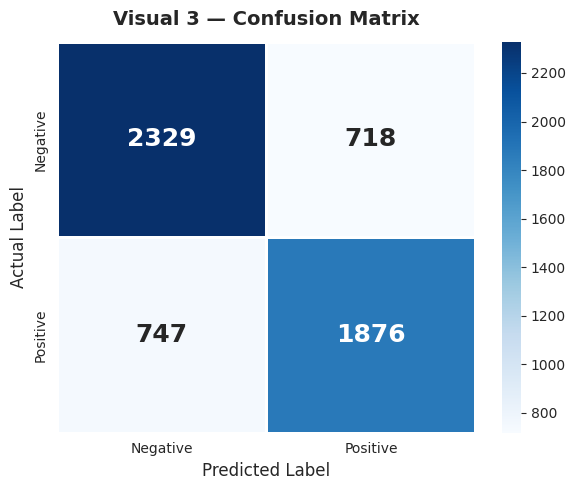

In [ ]:
# VISUAL 3 — Confusion Matrix

cm = confusion_matrix(y_test, preds, labels=['negative', 'positive'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            ax=ax, annot_kws={'size': 18, 'fontweight': 'bold'},
            linewidths=2, linecolor='white')
ax.set_title('Visual 3 — Confusion Matrix', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.show()

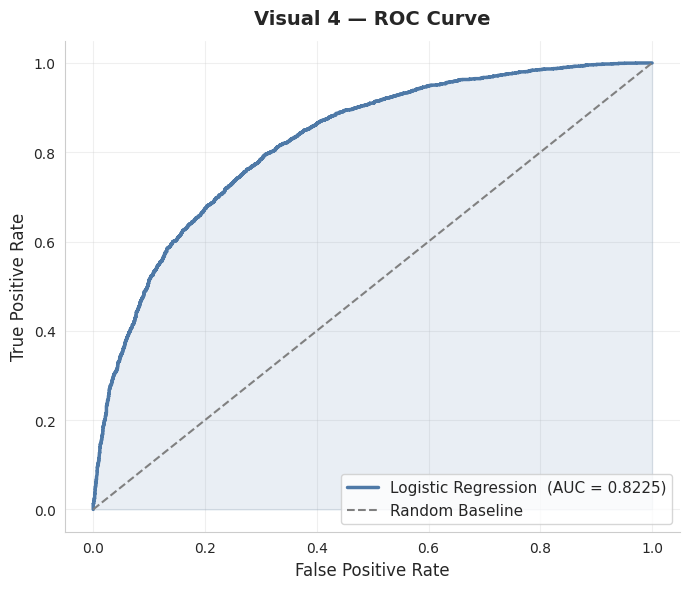

In [ ]:
# VISUAL 4 — ROC Curve

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#4e79a7', lw=2.5,
        label=f'Logistic Regression  (AUC = {roc_auc:.4f})')
ax.fill_between(fpr, tpr, alpha=0.12, color='#4e79a7')
ax.plot([0, 1], [0, 1], '--', color='gray', lw=1.5, label='Random Baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Visual 4 — ROC Curve', fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

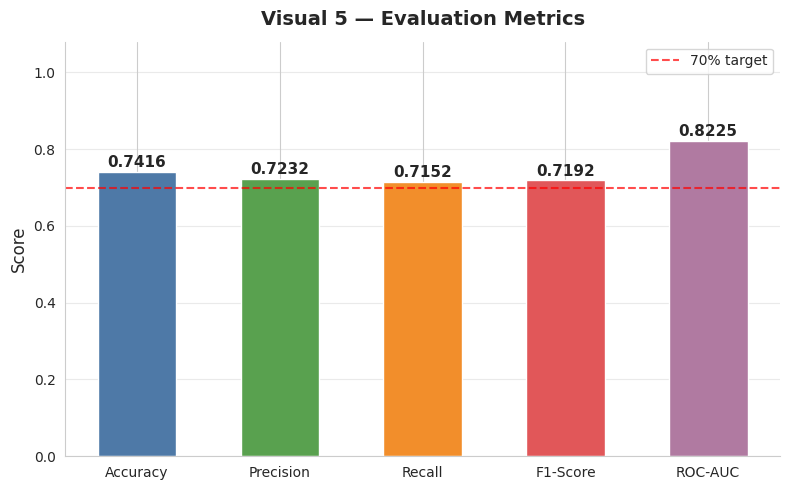

In [ ]:
# VISUAL 5 — Evaluation Metrics Bar Chart

m_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
m_values = [acc, prec, rec, f1, roc_auc]
m_colors = ['#4e79a7', '#59a14f', '#f28e2b', '#e15759', '#b07aa1']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(m_names, m_values, color=m_colors,
              edgecolor='white', zorder=2, width=0.55)
for bar, val in zip(bars, m_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Visual 5 — Evaluation Metrics', fontsize=14, fontweight='bold', pad=12)
ax.axhline(0.70, color='red', linestyle='--', lw=1.5, alpha=0.7, label='70% target')
ax.legend(fontsize=10)
ax.yaxis.grid(True, alpha=0.4, zorder=0)
sns.despine()
plt.tight_layout()
plt.show()

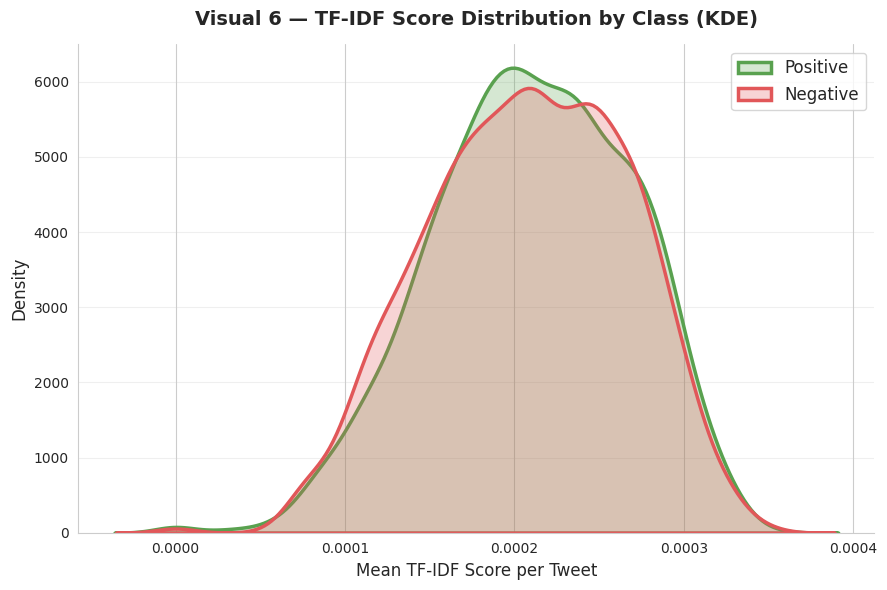

In [ ]:
# VISUAL 6 — KDE Plot: TF-IDF Score and  Distribution by Class
tfidf_dense = Xte.toarray()
mean_tfidf  = tfidf_dense.mean(axis=1)

tfidf_df = pd.DataFrame({
    'mean_tfidf': mean_tfidf,
    'label':      y_test.values
})

fig, ax = plt.subplots(figsize=(9, 6))
for label, color in [('positive', '#59a14f'), ('negative', '#e15759')]:
    subset = tfidf_df[tfidf_df['label'] == label]['mean_tfidf']
    ax.fill_between(
        *zip(*sorted(zip(
            np.linspace(subset.min(), subset.max(), 300),
            sns.kdeplot(subset, ax=ax, color=color, lw=2.5,
                        label=label.capitalize()).get_lines()[-1].get_data()[1]
                [:300] if len(sns.kdeplot(subset, ax=ax).get_lines()) > 0 else [0]*300
        ))), alpha=0.0
    )

ax.cla()
for label, color in [('positive', '#59a14f'), ('negative', '#e15759')]:
    subset = tfidf_df[tfidf_df['label'] == label]['mean_tfidf']
    sns.kdeplot(subset, ax=ax, color=color, lw=2.5,
                label=label.capitalize(), fill=True, alpha=0.25)

ax.set_title('Visual 6 — TF-IDF Score Distribution by Class (KDE)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Mean TF-IDF Score per Tweet', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=12)
ax.yaxis.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()